In [ ]:
import pandas as pd


In [ ]:
data = pd.read_csv('/content/Building_Permits_Sample.csv')
data

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201509015838,3,additions alterations or repairs,09/01/2015,7295,021,3251,NaN,20th,Av,...,2.0,constr type 2,2.0,constr type 2,NaN,7.0,Lakeshore,94132.0,"(37.728556952954136, -122.47676641508518)",1394184252862
1,201802131196,8,otc alterations permit,02/13/2018,0478,004,2811,NaN,Polk,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,2.0,Russian Hill,94109.0,"(37.80267692574757, -122.4233952674868)",1497053376862
2,201306189819,8,otc alterations permit,06/18/2013,1662,026,778,NaN,20th,Av,...,5.0,wood frame (5),5.0,wood frame (5),NaN,1.0,Outer Richmond,94121.0,"(37.77325109402815, -122.47853607225109)",1308402109047
3,201510159847,8,otc alterations permit,10/15/2015,3707,051,685,NaN,Market,St,...,1.0,constr type 1,1.0,constr type 1,NaN,6.0,Financial District/South Beach,94105.0,"(37.787646036408844, -122.40275877787255)",1399498164499
4,201404254181,7,wall or painted sign,04/25/2014,0286,022,519,NaN,Bush,St,...,NaN,NaN,NaN,NaN,NaN,3.0,Financial District/South Beach,94108.0,"(37.79031898807613, -122.4059843430652)",1339843361029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,201501024864,8,otc alterations permit,01/02/2015,1180,016,846,NaN,Divisadero,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,5.0,Western Addition,94117.0,"(37.77753837214031, -122.4379857311173)",1366622424887
381,201411040627,8,otc alterations permit,11/04/2014,0926,045,2377,NaN,Bay,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,2.0,Marina,94123.0,"(37.801198970632086, -122.44599396517357)",1361248291503
382,201503029648,8,otc alterations permit,03/02/2015,6634,024,165,NaN,29th,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,8.0,Noe Valley,94110.0,"(37.74364052569492, -122.42359557237067)",1372920262408
383,201705197127,8,otc alterations permit,05/19/2017,3642,001,3201,NaN,23rd,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,9.0,Mission,94110.0,"(37.7537472220182, -122.41667534898198)",1463839163667


In [ ]:
print(data.head())

  Permit Number  Permit Type            Permit Type Definition  \
0  201509015838            3  additions alterations or repairs   
1  201802131196            8            otc alterations permit   
2  201306189819            8            otc alterations permit   
3  201510159847            8            otc alterations permit   
4  201404254181            7              wall or painted sign   

  Permit Creation Date Block  Lot  Street Number Street Number Suffix  \
0           09/01/2015  7295  021           3251                  NaN   
1           02/13/2018  0478  004           2811                  NaN   
2           06/18/2013  1662  026            778                  NaN   
3           10/15/2015  3707  051            685                  NaN   
4           04/25/2014  0286  022            519                  NaN   

  Street Name Street Suffix  ...  Existing Construction Type  \
0        20th            Av  ...                         2.0   
1        Polk            St  ...    

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 43 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Permit Number                           385 non-null    object 
 1   Permit Type                             385 non-null    int64  
 2   Permit Type Definition                  385 non-null    object 
 3   Permit Creation Date                    385 non-null    object 
 4   Block                                   385 non-null    object 
 5   Lot                                     385 non-null    object 
 6   Street Number                           385 non-null    int64  
 7   Street Number Suffix                    5 non-null      object 
 8   Street Name                             385 non-null    object 
 9   Street Suffix                           378 non-null    object 
 10  Unit                                    44 non-null     float6

In [ ]:
print("\nValores faltantes por columna:")
missing_data = data.isnull().sum()
print(missing_data)


Valores faltantes por columna:
Permit Number                               0
Permit Type                                 0
Permit Type Definition                      0
Permit Creation Date                        0
Block                                       0
Lot                                         0
Street Number                               0
Street Number Suffix                      380
Street Name                                 0
Street Suffix                               7
Unit                                      341
Unit Suffix                               379
Description                                 2
Current Status                              0
Current Status Date                         0
Filed Date                                  0
Issued Date                                29
Completed Date                            199
First Construction Document Date           29
Structural Notification                   376
Number of Existing Stories                 93
Nu

In [ ]:
# Identificar columnas con más del 90% de valores nulos
threshold = 0.9
cols_to_drop = [col for col in data.columns if data[col].isnull().mean() > threshold]

# Eliminar las columnas identificadas
data = data.drop(columns=cols_to_drop)

# Mostrar columnas eliminadas
print("Columnas eliminadas:", cols_to_drop)


Columnas eliminadas: ['Street Number Suffix', 'Unit Suffix', 'Structural Notification', 'Voluntary Soft-Story Retrofit', 'Fire Only Permit', 'TIDF Compliance', 'Site Permit']


In [ ]:
data

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Name,Street Suffix,Unit,...,Plansets,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201509015838,3,additions alterations or repairs,09/01/2015,7295,021,3251,20th,Av,NaN,...,2.0,2.0,constr type 2,2.0,constr type 2,7.0,Lakeshore,94132.0,"(37.728556952954136, -122.47676641508518)",1394184252862
1,201802131196,8,otc alterations permit,02/13/2018,0478,004,2811,Polk,St,NaN,...,2.0,5.0,wood frame (5),5.0,wood frame (5),2.0,Russian Hill,94109.0,"(37.80267692574757, -122.4233952674868)",1497053376862
2,201306189819,8,otc alterations permit,06/18/2013,1662,026,778,20th,Av,NaN,...,0.0,5.0,wood frame (5),5.0,wood frame (5),1.0,Outer Richmond,94121.0,"(37.77325109402815, -122.47853607225109)",1308402109047
3,201510159847,8,otc alterations permit,10/15/2015,3707,051,685,Market,St,NaN,...,2.0,1.0,constr type 1,1.0,constr type 1,6.0,Financial District/South Beach,94105.0,"(37.787646036408844, -122.40275877787255)",1399498164499
4,201404254181,7,wall or painted sign,04/25/2014,0286,022,519,Bush,St,NaN,...,2.0,NaN,NaN,NaN,NaN,3.0,Financial District/South Beach,94108.0,"(37.79031898807613, -122.4059843430652)",1339843361029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,201501024864,8,otc alterations permit,01/02/2015,1180,016,846,Divisadero,St,NaN,...,0.0,5.0,wood frame (5),5.0,wood frame (5),5.0,Western Addition,94117.0,"(37.77753837214031, -122.4379857311173)",1366622424887
381,201411040627,8,otc alterations permit,11/04/2014,0926,045,2377,Bay,St,0.0,...,0.0,5.0,wood frame (5),5.0,wood frame (5),2.0,Marina,94123.0,"(37.801198970632086, -122.44599396517357)",1361248291503
382,201503029648,8,otc alterations permit,03/02/2015,6634,024,165,29th,St,NaN,...,0.0,5.0,wood frame (5),5.0,wood frame (5),8.0,Noe Valley,94110.0,"(37.74364052569492, -122.42359557237067)",1372920262408
383,201705197127,8,otc alterations permit,05/19/2017,3642,001,3201,23rd,St,NaN,...,2.0,5.0,wood frame (5),5.0,wood frame (5),9.0,Mission,94110.0,"(37.7537472220182, -122.41667534898198)",1463839163667


In [ ]:
# Eliminar filas con valores nulos en columnas críticas
critical_cols = ['Issued Date', 'Completed Date', 'Location']
data = data.dropna(subset=critical_cols)

# Verificar filas eliminadas
print(f"Filas restantes después de eliminar nulos en {critical_cols}: {data.shape[0]}")


Filas restantes después de eliminar nulos en ['Issued Date', 'Completed Date', 'Location']: 186


In [ ]:
# Imputar valores numéricos con la mediana
num_cols = ['Number of Existing Stories', 'Estimated Cost', 'Existing Units', 'Proposed Units']
for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

# Verificar imputación
print("Valores nulos después de imputación numérica:")
print(data[num_cols].isnull().sum())


Valores nulos después de imputación numérica:
Number of Existing Stories    0
Estimated Cost                0
Existing Units                0
Proposed Units                0
dtype: int64


<ipython-input-14-2060367dca05>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
<ipython-input-14-2060367dca05>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col].fillna(data[col].median(), inplace=True)


In [ ]:
# Imputar valores categóricos con la moda
cat_cols = ['Existing Use', 'Proposed Use', 'Existing Construction Type Description']
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

# Verificar imputación
print("Valores nulos después de imputación categórica:")
print(data[cat_cols].isnull().sum())


Valores nulos después de imputación categórica:
Existing Use                              0
Proposed Use                              0
Existing Construction Type Description    0
dtype: int64


<ipython-input-15-5dea9e84e06e>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
<ipython-input-15-5dea9e84e06e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
print(data[cat_cols].isnull().sum())

Existing Use                              0
Proposed Use                              0
Existing Construction Type Description    0
dtype: int64


In [ ]:
# Imputar fechas faltantes con un valor específico
date_cols = ['Completed Date', 'Permit Expiration Date']
for col in date_cols:
    data[col] = data[col].fillna("Unknown")

# Verificar imputación
print("Valores nulos después de imputación de fechas:")
print(data[date_cols].isnull().sum())



Valores nulos después de imputación de fechas:
Completed Date            0
Permit Expiration Date    0
dtype: int64


<ipython-input-19-59b5c28b2164>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = data[col].fillna("Unknown")


,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Name,Street Suffix,Unit,...,Plansets_missing,Existing Construction Type_missing,Existing Construction Type Description_missing,Proposed Construction Type_missing,Proposed Construction Type Description_missing,Supervisor District_missing,Neighborhoods - Analysis Boundaries_missing,Zipcode_missing,Location_missing,Record ID_missing
2,201306189819,8,otc alterations permit,06/18/2013,1662,026,778,20th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
3,201510159847,8,otc alterations permit,10/15/2015,3707,051,685,Market,St,NaN,...,0,0,0,0,0,0,0,0,0,0
7,201404223876,8,otc alterations permit,04/22/2014,1520,019,590,25th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
9,201409105960,8,otc alterations permit,09/10/2014,1054,026,2887,Bush,St,NaN,...,0,0,0,0,0,0,0,0,0,0
12,201309237453,8,otc alterations permit,09/23/2013,2201,003B,636,Rivera,St,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,201305156955,8,otc alterations permit,05/15/2013,7295,021,3251,20th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
375,201509025985,8,otc alterations permit,09/02/2015,7211,002,3021,26th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
379,201703201818,8,otc alterations permit,03/20/2017,7238,012,76,Denslowe,Dr,NaN,...,0,0,0,0,0,0,0,0,0,0
382,201503029648,8,otc alterations permit,03/02/2015,6634,024,165,29th,St,NaN,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Name,Street Suffix,Unit,...,Plansets_missing,Existing Construction Type_missing,Existing Construction Type Description_missing,Proposed Construction Type_missing,Proposed Construction Type Description_missing,Supervisor District_missing,Neighborhoods - Analysis Boundaries_missing,Zipcode_missing,Location_missing,Record ID_missing
2,201306189819,8,otc alterations permit,06/18/2013,1662,026,778,20th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
3,201510159847,8,otc alterations permit,10/15/2015,3707,051,685,Market,St,NaN,...,0,0,0,0,0,0,0,0,0,0
7,201404223876,8,otc alterations permit,04/22/2014,1520,019,590,25th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
9,201409105960,8,otc alterations permit,09/10/2014,1054,026,2887,Bush,St,NaN,...,0,0,0,0,0,0,0,0,0,0
12,201309237453,8,otc alterations permit,09/23/2013,2201,003B,636,Rivera,St,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,201305156955,8,otc alterations permit,05/15/2013,7295,021,3251,20th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
375,201509025985,8,otc alterations permit,09/02/2015,7211,002,3021,26th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
379,201703201818,8,otc alterations permit,03/20/2017,7238,012,76,Denslowe,Dr,NaN,...,0,0,0,0,0,0,0,0,0,0
382,201503029648,8,otc alterations permit,03/02/2015,6634,024,165,29th,St,NaN,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Crear columnas binarias que indiquen valores nulos
for col in data.columns:
    data[f"{col}_missing"] = data[col].isnull().astype(int)

# Verificar creación de columnas
print("Columnas de flags creadas para datos faltantes.")


Columnas de flags creadas para datos faltantes.


<ipython-input-18-0a9203c89dc1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f"{col}_missing"] = data[col].isnull().astype(int)
<ipython-input-18-0a9203c89dc1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f"{col}_missing"] = data[col].isnull().astype(int)
<ipython-input-18-0a9203c89dc1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

In [ ]:
data

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Name,Street Suffix,Unit,...,Plansets_missing,Existing Construction Type_missing,Existing Construction Type Description_missing,Proposed Construction Type_missing,Proposed Construction Type Description_missing,Supervisor District_missing,Neighborhoods - Analysis Boundaries_missing,Zipcode_missing,Location_missing,Record ID_missing
2,201306189819,8,otc alterations permit,06/18/2013,1662,026,778,20th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
3,201510159847,8,otc alterations permit,10/15/2015,3707,051,685,Market,St,NaN,...,0,0,0,0,0,0,0,0,0,0
7,201404223876,8,otc alterations permit,04/22/2014,1520,019,590,25th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
9,201409105960,8,otc alterations permit,09/10/2014,1054,026,2887,Bush,St,NaN,...,0,0,0,0,0,0,0,0,0,0
12,201309237453,8,otc alterations permit,09/23/2013,2201,003B,636,Rivera,St,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,201305156955,8,otc alterations permit,05/15/2013,7295,021,3251,20th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
375,201509025985,8,otc alterations permit,09/02/2015,7211,002,3021,26th,Av,NaN,...,0,0,0,0,0,0,0,0,0,0
379,201703201818,8,otc alterations permit,03/20/2017,7238,012,76,Denslowe,Dr,NaN,...,0,0,0,0,0,0,0,0,0,0
382,201503029648,8,otc alterations permit,03/02/2015,6634,024,165,29th,St,NaN,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Verificar valores nulos restantes
print("Valores nulos restantes por columna:")
print(data.isnull().sum())


Valores nulos restantes por columna:
Permit Number                                  0
Permit Type                                    0
Permit Type Definition                         0
Permit Creation Date                           0
Block                                          0
                                              ..
Supervisor District_missing                    0
Neighborhoods - Analysis Boundaries_missing    0
Zipcode_missing                                0
Location_missing                               0
Record ID_missing                              0
Length: 72, dtype: int64


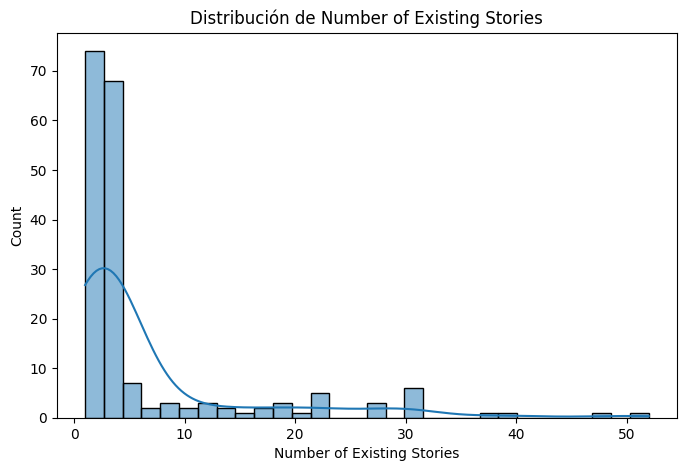

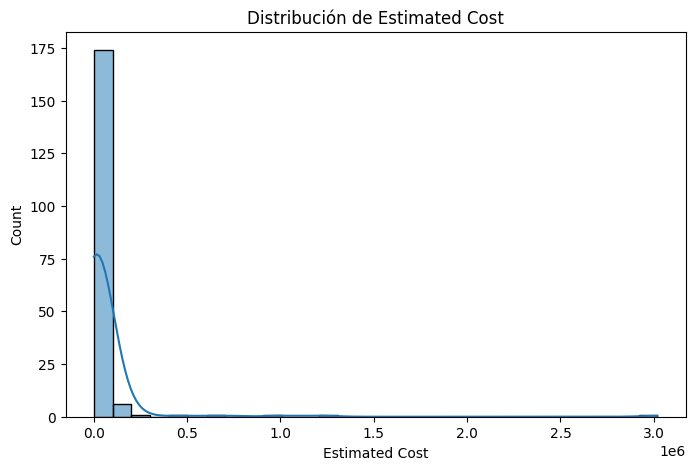

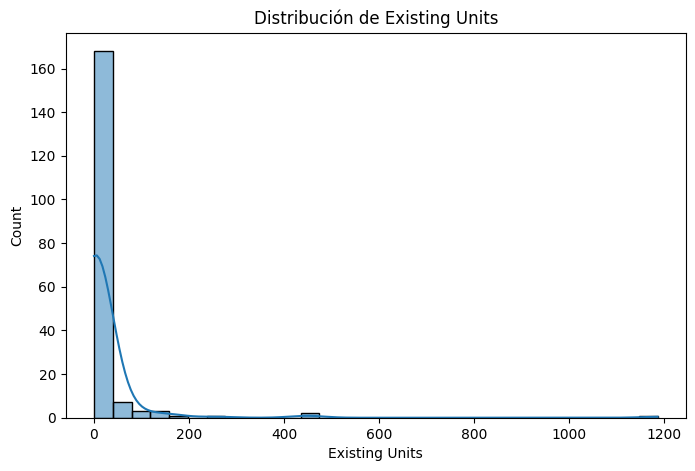

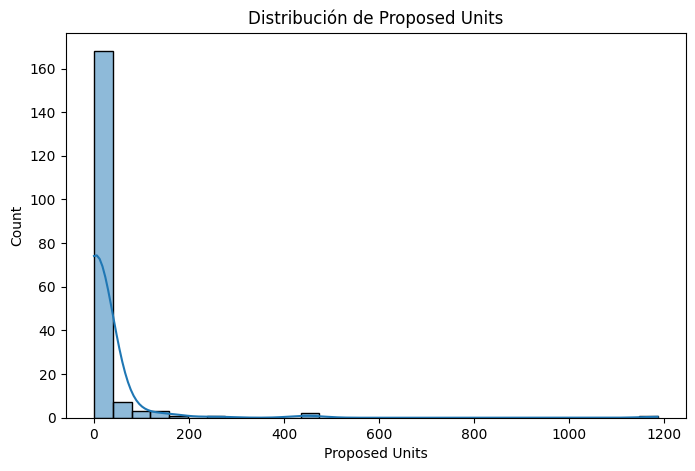

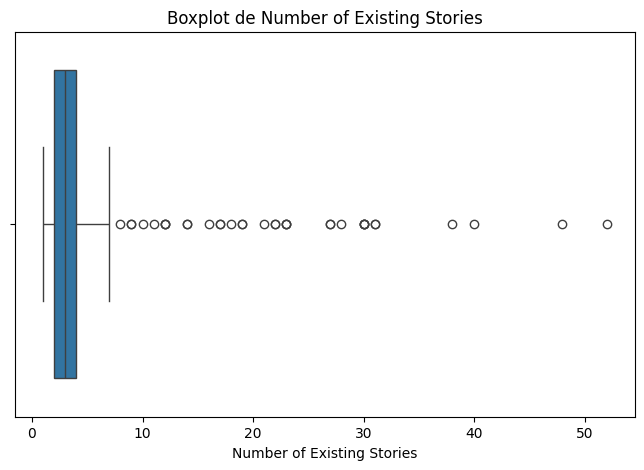

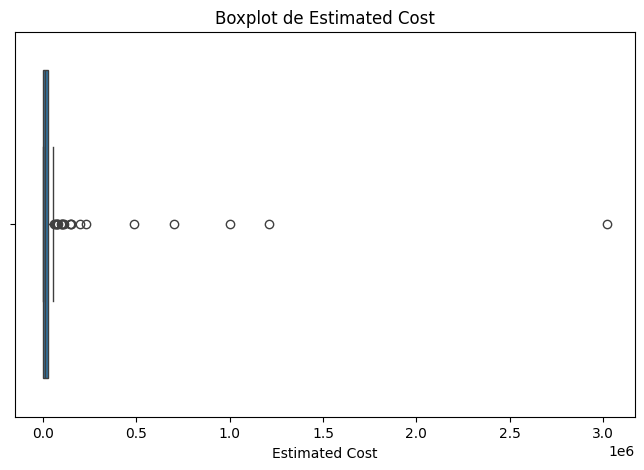

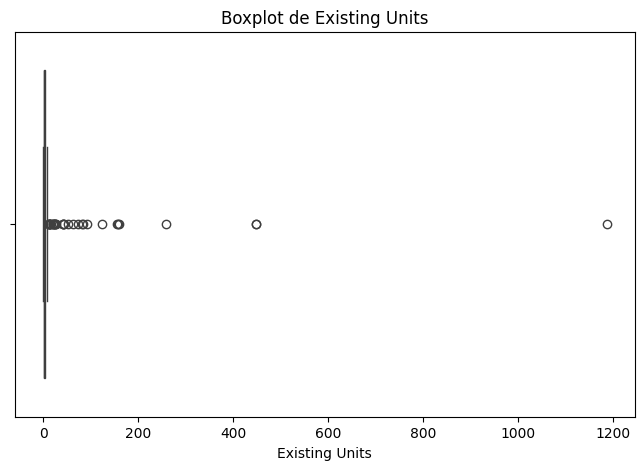

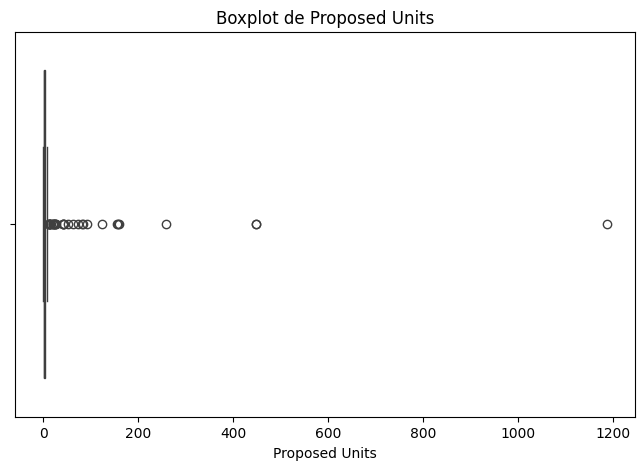

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de variables numéricas
num_cols = ['Number of Existing Stories', 'Estimated Cost', 'Existing Units', 'Proposed Units']
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.show()

# Boxplots para detectar outliers
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot de {col}')
    plt.show()


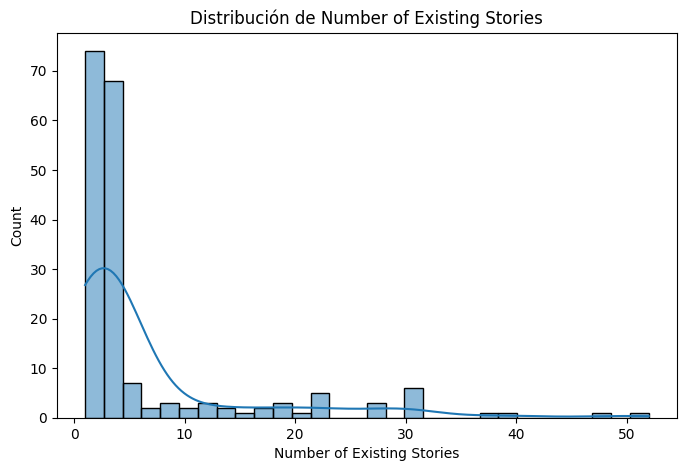

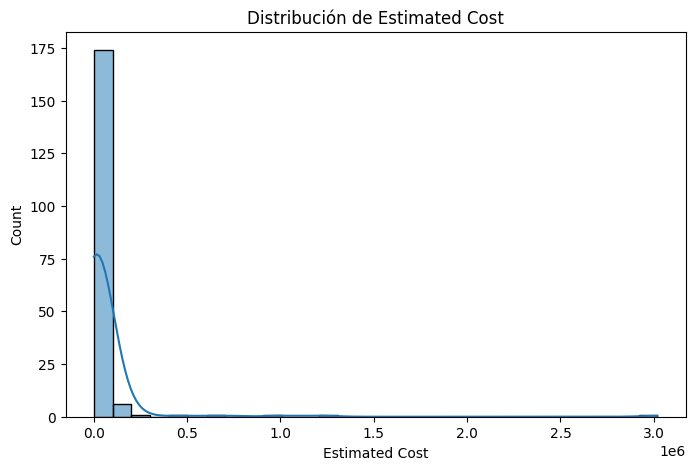

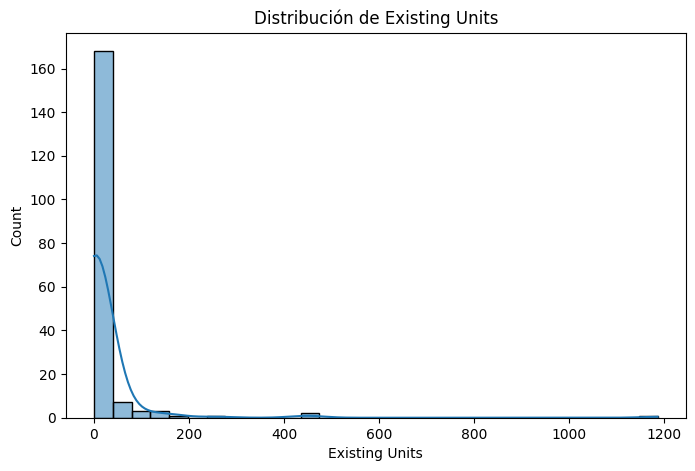

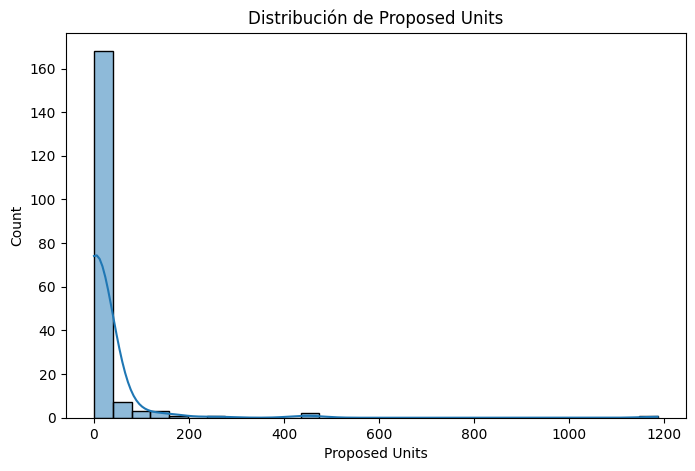

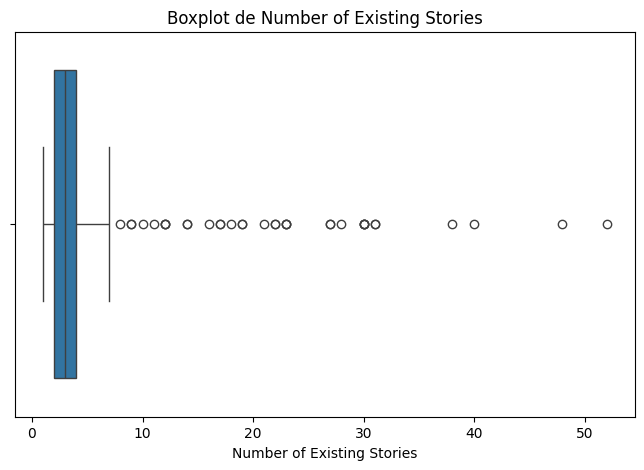

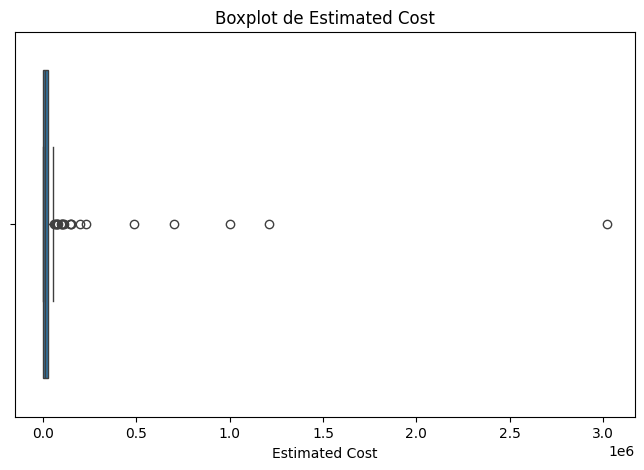

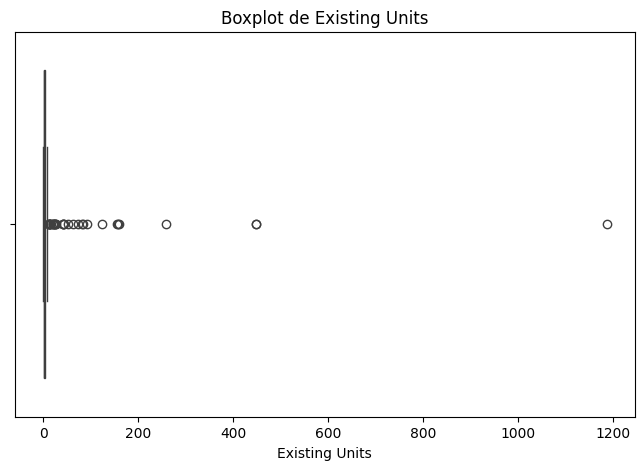

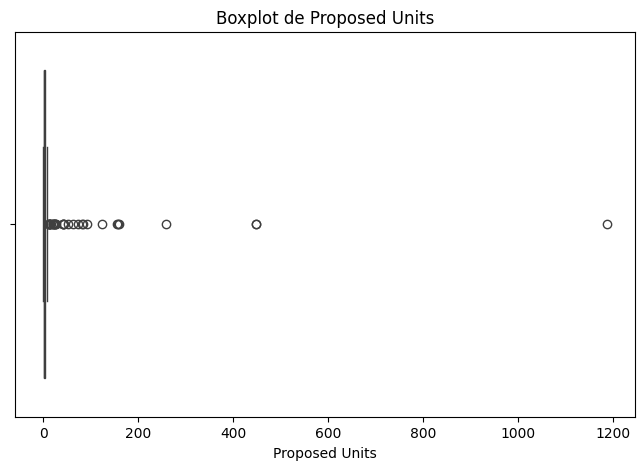

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de variables numéricas
num_cols = ['Number of Existing Stories', 'Estimated Cost', 'Existing Units', 'Proposed Units']
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.show()

# Boxplots para detectar outliers
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot de {col}')
    plt.show()


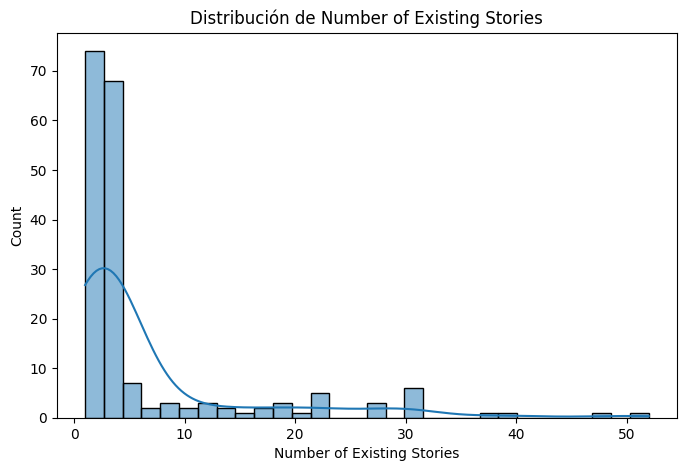

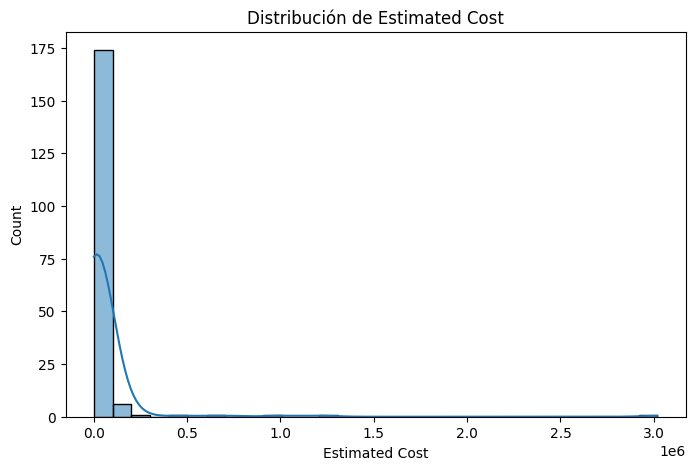

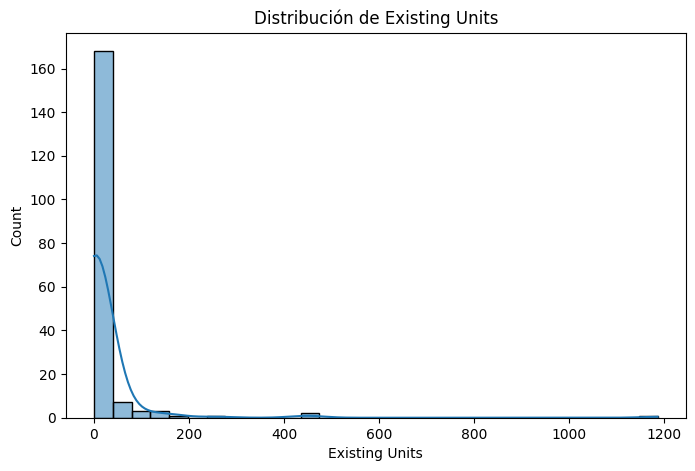

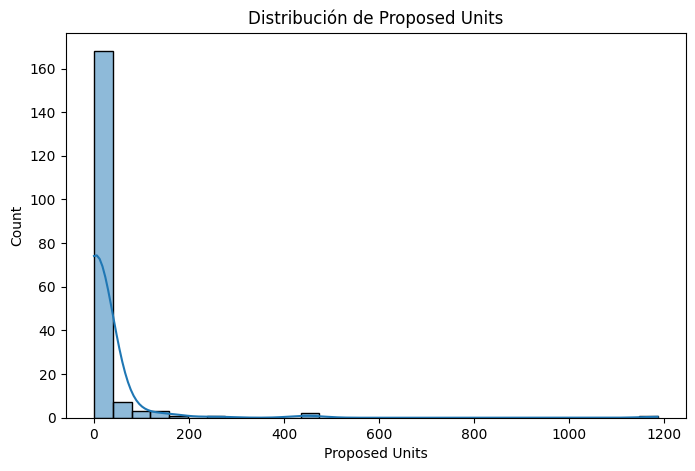

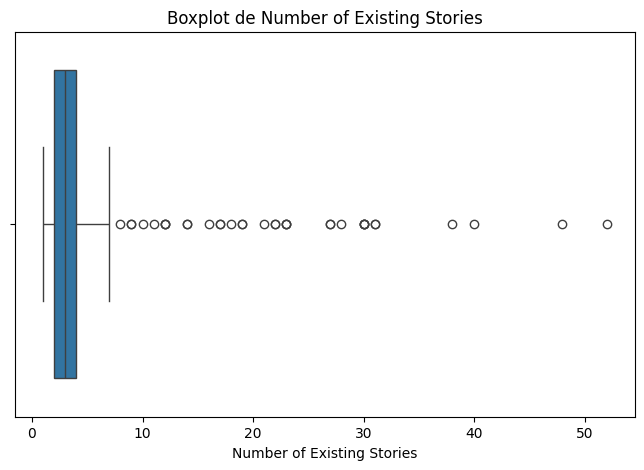

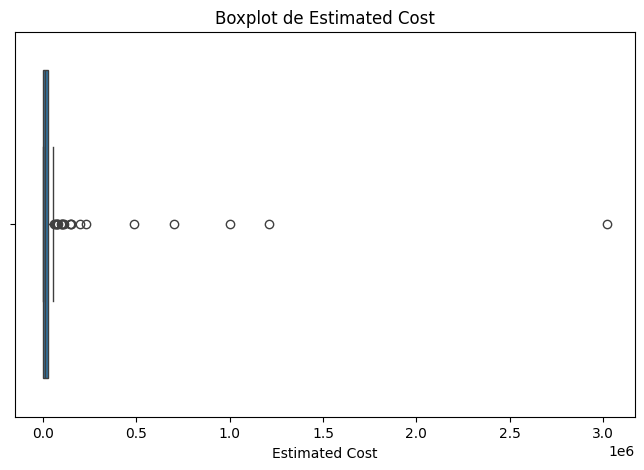

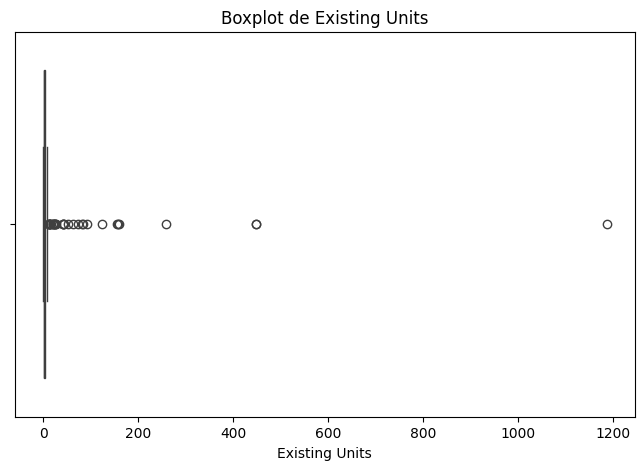

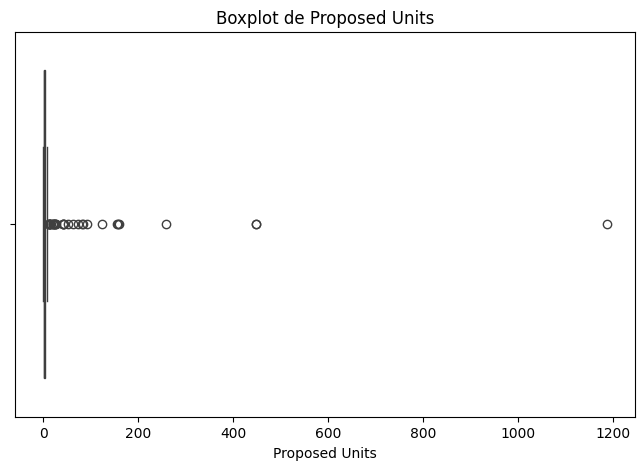

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de variables numéricas
num_cols = ['Number of Existing Stories', 'Estimated Cost', 'Existing Units', 'Proposed Units']
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.show()

# Boxplots para detectar outliers
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot de {col}')
    plt.show()


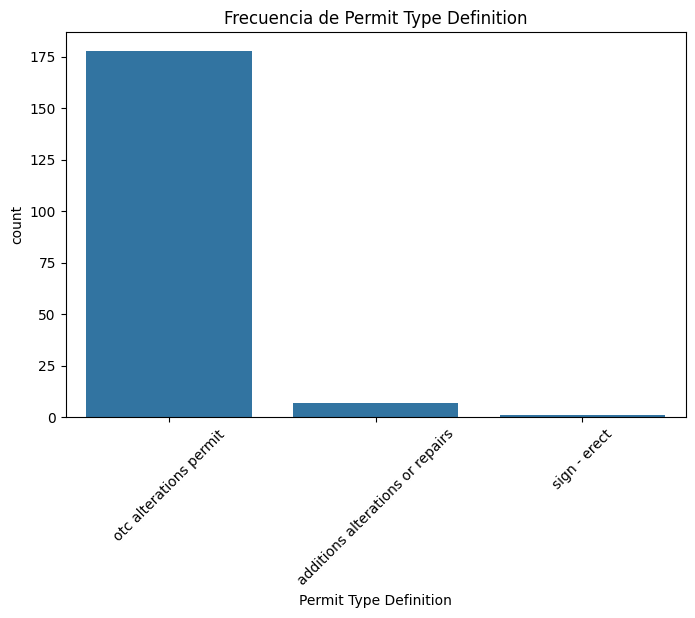

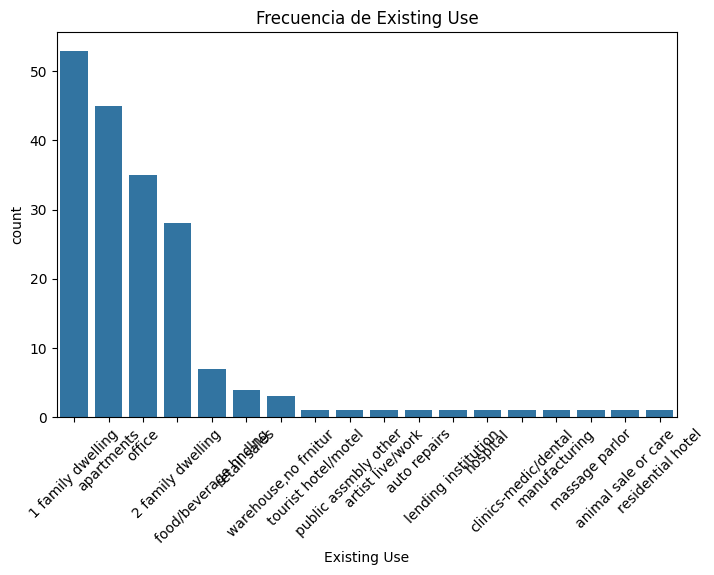

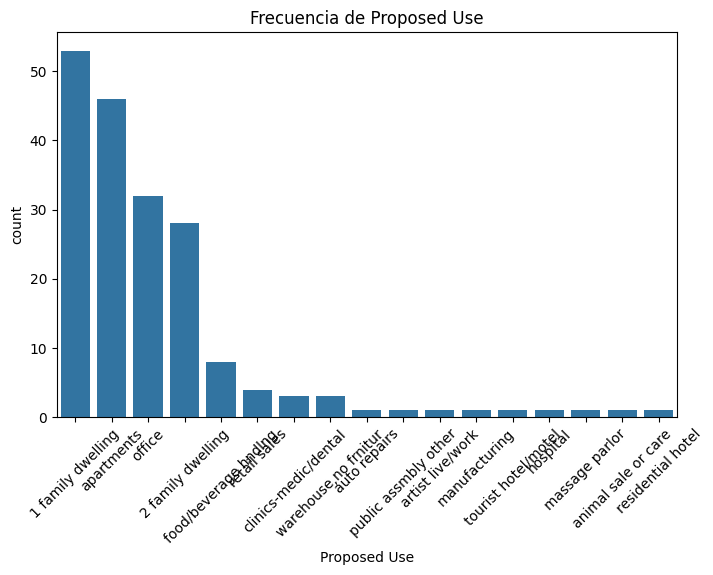

In [ ]:
# Gráfico de barras para variables categóricas
cat_cols = ['Permit Type Definition', 'Existing Use', 'Proposed Use']
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=data[col], order=data[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Frecuencia de {col}')
    plt.show()


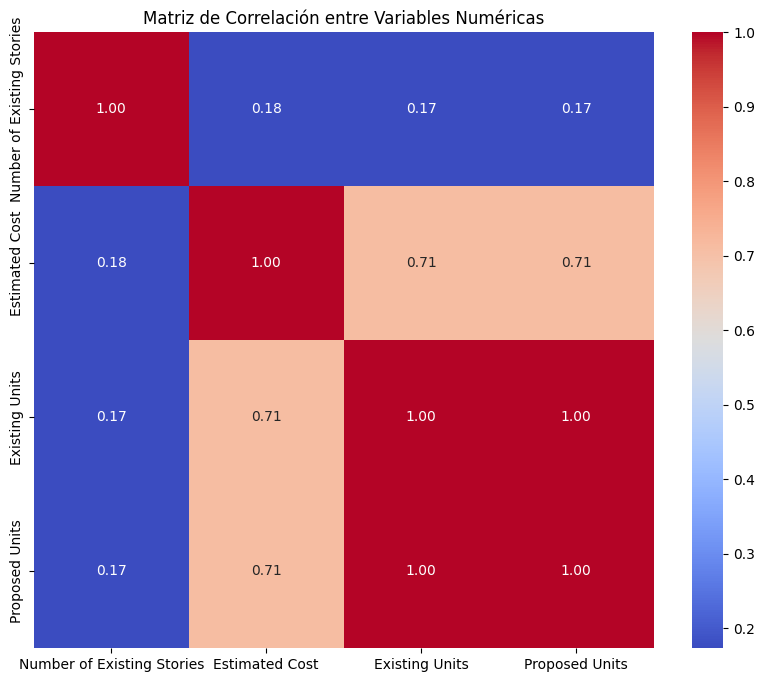

In [ ]:
# Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()


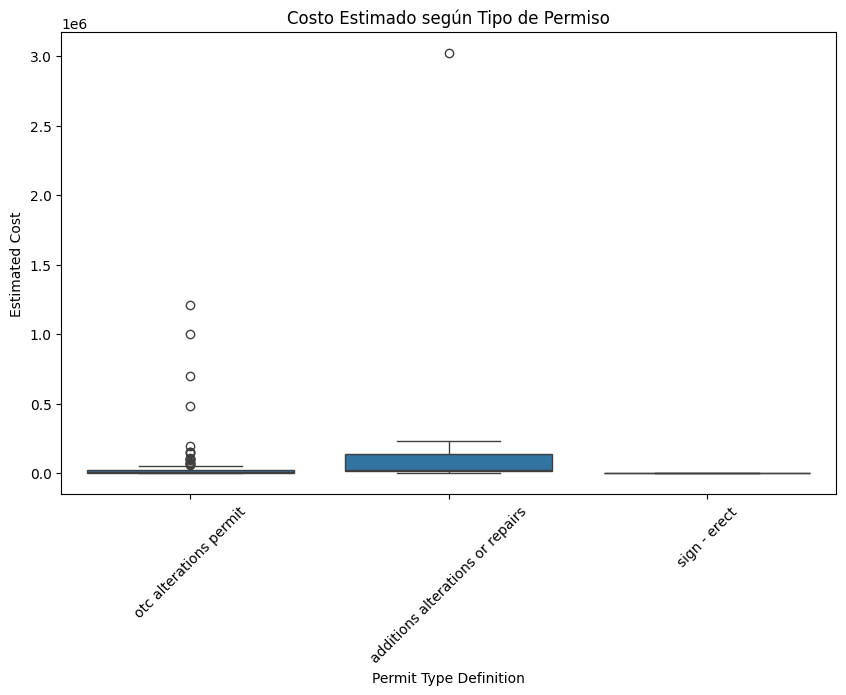

In [ ]:
# Boxplot de Estimated Cost agrupado por Permit Type Definition
plt.figure(figsize=(10, 6))
sns.boxplot(x='Permit Type Definition', y='Estimated Cost', data=data)
plt.xticks(rotation=45)
plt.title("Costo Estimado según Tipo de Permiso")
plt.show()


<ipython-input-30-ab78ce1eca17>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Weekday'] = pd.to_datetime(data['Permit Creation Date']).dt.day_name()


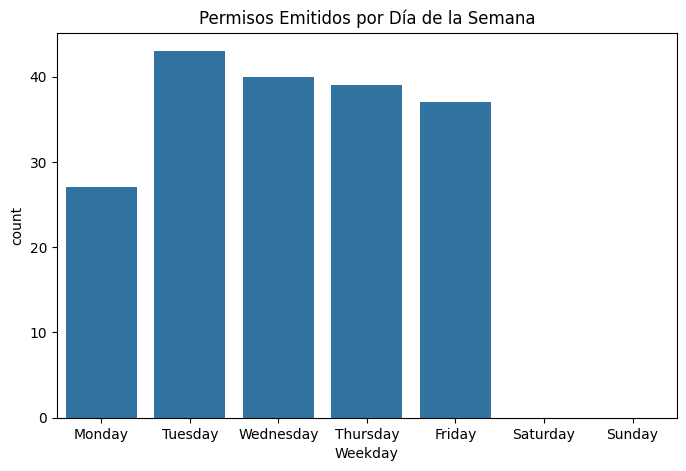

In [ ]:
# Extraer día de la semana
data['Weekday'] = pd.to_datetime(data['Permit Creation Date']).dt.day_name()

# Gráfico de permisos emitidos por día de la semana
plt.figure(figsize=(8, 5))
sns.countplot(x='Weekday', data=data, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title("Permisos Emitidos por Día de la Semana")
plt.show()


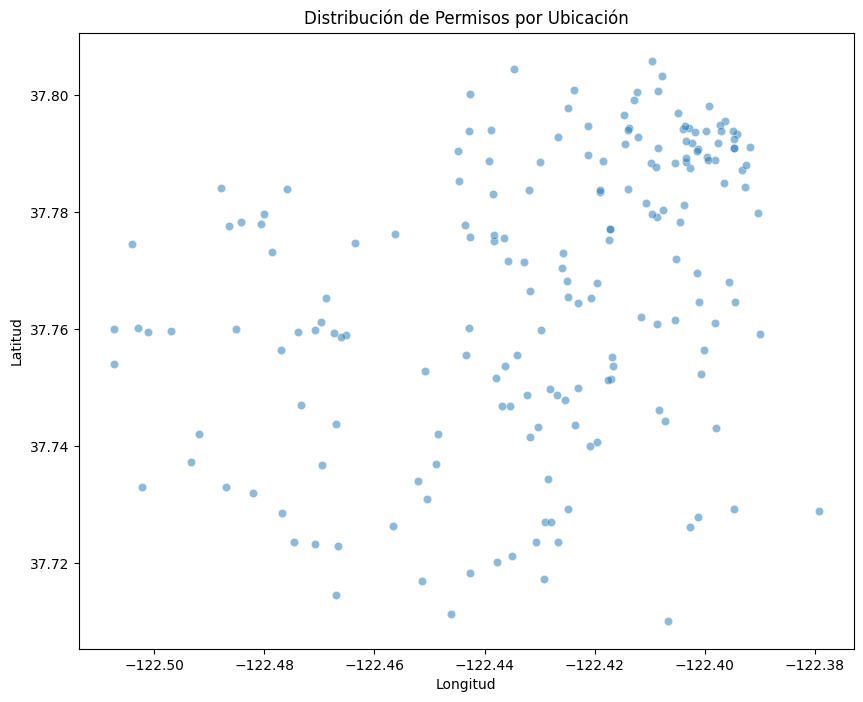

In [ ]:
# Gráfico de puntos con ubicaciones
plt.figure(figsize=(10, 8))
sns.scatterplot(x=data['Location'].apply(lambda x: eval(x)[1]),
                y=data['Location'].apply(lambda x: eval(x)[0]),
                alpha=0.5)
plt.title("Distribución de Permisos por Ubicación")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


In [ ]:
pip install folium


In [ ]:
import folium
from folium.plugins import HeatMap

# Crear un mapa centrado en San Francisco
san_francisco_map = folium.Map(location=[37.7749, -122.4194], zoom_start=12)

# Extraer latitud y longitud
data['Latitude'] = data['Location'].apply(lambda x: eval(x)[0] if pd.notnull(x) else None)
data['Longitude'] = data['Location'].apply(lambda x: eval(x)[1] if pd.notnull(x) else None)

# Agregar puntos al mapa
for lat, lon in zip(data['Latitude'], data['Longitude']):
    if pd.notnull(lat) and pd.notnull(lon):
        folium.CircleMarker(
            location=[lat, lon],
            radius=2,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.5
        ).add_to(san_francisco_map)

# Mostrar el mapa
san_francisco_map


<ipython-input-33-c19c6fbedf78>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Latitude'] = data['Location'].apply(lambda x: eval(x)[0] if pd.notnull(x) else None)
<ipython-input-33-c19c6fbedf78>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Longitude'] = data['Location'].apply(lambda x: eval(x)[1] if pd.notnull(x) else None)
